In [1]:
from five_bar.five_bar import five_bar
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

robot = five_bar(SERIAL_PORT="COM16", max_speed=100)
robot.set_control_mode("position")

target1=135
target2=-135

robot.set_target(target1,target2)

robot.start()

time.sleep(2)


Initializing Robot...

Connecting to CAN bus COM16...
Successfully connected to CAN bus COM16!

Robot Initialized. 
Defaulting to control mode: 'torque'
Start threads to begin using the robot

Control Mode set to 'position'. Setting targets to [0,0]

Starting Read/write threads...
Read/write threads started!



Control Mode set to 'torque'. Setting targets to [0,0]

Aborting: Motors reached maximum allowed speed, setting control mode to torque and setting targets to [0,0]


In [2]:
theta1_pick=177.97408142381062
theta2_pick=-108.94326081883368

theta1_place=108.94326081883368
theta2_place=-177.97408142381062

In [20]:
robot.set_control_mode("position")
robot.set_target(theta1_pick,theta2_pick)

Robot is inactive. Setting target unavailable. Please restart.



In [4]:
def cubic_trajectory(theta_i, theta_f, speed_i, speed_f, T):
    """
    Returns the coefficients [a0, a1, a2, a3] of the cubic polynomial:
    θ(t) = a0 + a1*t + a2*t^2 + a3*t^3
    """

    a0 = theta_i
    a1 = speed_i

    a2 = (3*(theta_f - theta_i) - (2*speed_i + speed_f)*T) / T**2
    a3 = (2*(theta_i - theta_f) + (speed_i + speed_f)*T) / T**3

    return [a0, a1, a2, a3]

def evaluate_cubic_and_derivative(coeffs, t,T):
    """
    Returns θ(t) and θ̇(t) for a cubic polynomial defined by coeffs.
    """
    a0, a1, a2, a3 = coeffs
    
    t = max(0, min(t, T))
    
    theta = a0 + a1*t + a2*t**2 + a3*t**3
    theta_dot = a1 + 2*a2*t + 3*a3*t**2
    return [theta, theta_dot]

In [16]:
trajectory_time=1

#Coeffs to go
coeffs_theta1_go = cubic_trajectory(theta_i=theta1_pick, theta_f=theta1_place, speed_i=0, speed_f=0, T=trajectory_time)
coeffs_theta2_go = cubic_trajectory(theta_i=theta2_pick, theta_f=theta2_place, speed_i=0, speed_f=0, T=trajectory_time)

#Coeffs to back
coeffs_theta1_back = cubic_trajectory(theta_i=theta1_place, theta_f=theta1_pick, speed_i=0, speed_f=0, T=trajectory_time)
coeffs_theta2_back = cubic_trajectory(theta_i=theta2_place, theta_f=theta2_pick, speed_i=0, speed_f=0, T=trajectory_time)

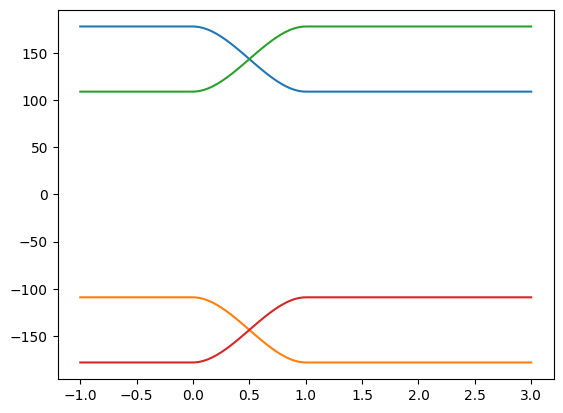

In [17]:
times=np.linspace(-1,3,100)
plt.plot(times,[evaluate_cubic_and_derivative(coeffs_theta1_go,time,trajectory_time)[0] for time in times])
plt.plot(times,[evaluate_cubic_and_derivative(coeffs_theta2_go,time,trajectory_time)[0] for time in times])
plt.plot(times,[evaluate_cubic_and_derivative(coeffs_theta1_back,time,trajectory_time)[0] for time in times])
plt.plot(times,[evaluate_cubic_and_derivative(coeffs_theta2_back,time,trajectory_time)[0] for time in times])

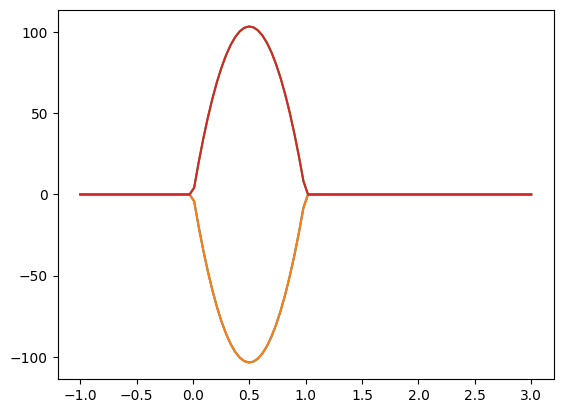

In [18]:
plt.plot(times,[evaluate_cubic_and_derivative(coeffs_theta1_go,time,trajectory_time)[1] for time in times])
plt.plot(times,[evaluate_cubic_and_derivative(coeffs_theta2_go,time,trajectory_time)[1] for time in times])
plt.plot(times,[evaluate_cubic_and_derivative(coeffs_theta1_back,time,trajectory_time)[1] for time in times])
plt.plot(times,[evaluate_cubic_and_derivative(coeffs_theta2_back,time,trajectory_time)[1] for time in times])

In [19]:
robot.set_control_mode("torque")

t_0=time.time()
while True:
    actual_time=time.time()-t_0
    objective_angle_theta1=evaluate_cubic_and_derivative(coeffs_theta1_go,actual_time,trajectory_time)[0]
    objective_angle_theta2=evaluate_cubic_and_derivative(coeffs_theta2_go,actual_time,trajectory_time)[0]
    
    objective_speed_theta1=evaluate_cubic_and_derivative(coeffs_theta1_go,actual_time,trajectory_time)[1]
    objective_speed_theta2=evaluate_cubic_and_derivative(coeffs_theta2_go,actual_time,trajectory_time)[1]
    
    data=robot.get_motors_data()
    
    actual_theta1=data["angle"][0]
    actual_theta2=data["angle"][1]
    
    actual_speed1=data["speed"][0]
    actual_speed2=data["speed"][1]
    
    target1=0.1*(objective_angle_theta1-actual_theta1)+0.01*(objective_speed_theta1-actual_speed1)
    target2=0.1*(objective_angle_theta2-actual_theta2)+0.01*(objective_speed_theta2-actual_speed2)
    
    robot.set_target(target1,target2)
    
    time.sleep(0.01)

Control Mode set to 'torque'. Setting targets to [0,0]



KeyboardInterrupt: 

In [ ]:
robot.set_target(theta1_pick,theta2_pick)
time.sleep(1)
robot.set_target(theta1_place,theta2_place)
time.sleep(1)

In [ ]:
import matplotlib.pyplot as plt
plt.plot(datos["time"],datos["q2"])

In [ ]:


t_0=time.time()

i=0
it=len(datos['q1'])
while i<it:
    

    robot.set_target(np.rad2deg(datos['q1'][i]),np.rad2deg(datos['q2'][i]))
    
    print(", ".join([f"{angle:.2f}" for angle in robot.get_motors_data()["angle"]]))
    time.sleep(0.040202)
    i += 1 
